In [1]:
#Pelayo Leguina - 2024

#Este script permite convertir un archivo ROOT con clases tipo TClonesArray a un DataFrame de pandas.

# Para correr este script es necesario tener instalado ROOT y pandas
# Para tener root instalado, hay que generar el env con conda. 
# Mira el archivo environment.yml para ver como hacerlo. Una vez tengas el env creado, activa el env y ejecuta este notebook. 
# Puedes seguir trabajando aqui o exportar el dataframe a un archivo csv para trabajar en otro lado.

import ROOT
import pandas as pd

# Definir la ruta del archivo ROOT y el nombre del arbol
#DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0 (grande)
#DTDPGNtuple_12_4_2_Phase2Concentrator_Simulation_89
ruta_archivo_root = '../dtTuples/DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0.root'
nombre_arbol = 'dtNtupleProducer/DTTREE'

# Abrir el archivo ROOT
archivo = ROOT.TFile.Open(ruta_archivo_root)
if not archivo or archivo.IsZombie():
    raise FileNotFoundError(f"No se pudo abrir el archivo ROOT en {ruta_archivo_root}")

# Obtener el arbol
arbol = archivo.Get(nombre_arbol)
if not arbol:
    raise ValueError(f"No se encontro el arbol '{nombre_arbol}' en el archivo ROOT.")

# Obtener el numero de eventos en el arbol
numero_eventos = arbol.GetEntries()
print(f"El arbol tiene {numero_eventos} eventos.")

El arbol tiene 933000 eventos.


In [2]:

# Listas de ramas
ramas_event = ['event_eventNumber']
ramas_digis_numericas = ["digi_nDigis", "digi_wheel", "digi_sector", "digi_station", 
    "digi_superLayer", "digi_layer", "digi_wire", "digi_time"]
ramas_seg_numericas = [
    "seg_nSegments", "seg_wheel", "seg_sector", "seg_station", "seg_hasPhi", 
    "seg_hasZed", "seg_posLoc_x", "seg_posLoc_y", "seg_posLoc_z", 
    "seg_dirLoc_x", "seg_dirLoc_y", "seg_dirLoc_z", "seg_posLoc_x_SL1", 
    "seg_posLoc_x_SL3", "seg_posLoc_x_midPlane", "seg_posGlb_phi", 
    "seg_posGlb_eta", "seg_dirGlb_phi", "seg_dirGlb_eta", "seg_phi_t0", 
    "seg_phi_vDrift", "seg_phi_normChi2", "seg_phi_nHits", 
    "seg_z_normChi2", "seg_z_nHits"
]
ramas_seg_arrays = [
    'seg_phiHits_pos', 'seg_phiHits_posCh', 'seg_phiHits_posErr', 
    'seg_phiHits_side', 'seg_phiHits_wire', 'seg_phiHits_wirePos', 
    'seg_phiHits_layer', 'seg_phiHits_superLayer', 'seg_phiHits_time', 
    'seg_phiHits_timeCali'
]

ramas_a_extraer = ramas_event + ramas_digis_numericas + ramas_seg_numericas + ramas_seg_arrays


In [3]:
# Inicializar diccionario para almacenar los datos
data = {rama: [] for rama in ramas_a_extraer}

# Obtener el numero de eventos en el arbol
numero_eventos = arbol.GetEntries()
print(f"El arbol tiene {numero_eventos} eventos.")


El arbol tiene 933000 eventos.


In [4]:
from collections import defaultdict
import time

data = defaultdict(list)

max_eventos = 10000

start_total = time.time()

# Iterar sobre las entradas del arbol
for i, evento in enumerate(arbol):
    start_event = time.time()
    if i >= max_eventos:
        break  # Detener el bucle cuando se alcanzan max_eventos
    for rama in ramas_a_extraer:
        valor = getattr(evento, rama, None)
        
        if valor is None:
            data[rama].append(None)
            continue

        # Optimizacion: manejar TClonesArray
        if hasattr(valor, 'GetEntriesFast'):
            n_entries = valor.GetEntriesFast()  # Guardar numero de entradas
            valores = [
                [x for x in valor.At(i)] if hasattr(valor.At(i), '__len__') else valor.At(i)
                for i in range(n_entries)
            ]
            data[rama].append(valores)
        elif isinstance(valor, (ROOT.TVectorF, ROOT.TVectorD)):
            # Optimizacion: convertir directamente a lista
            data[rama].append(list(valor))
        elif isinstance(valor, (int, float)):
            # Escalar simple
            data[rama].append(valor)
        else:
            try:
                # Intentar convertir a lista si es iterable
                data[rama].append(list(valor))
            except TypeError:
                data[rama].append(valor)
    end_event = time.time()
    if i%1000==0:
        print(f"Evento {i+1}: {end_event - start_event:.2f} segundos")

end_total = time.time()
print(f"Tiempo total: {end_total - start_total:.2f} segundos")
# Cerrar el archivo ROOT
archivo.Close()
#tarda como 1 minuto

Evento 1: 0.07 segundos
Evento 1001: 0.00 segundos
Evento 2001: 0.00 segundos
Evento 3001: 0.00 segundos
Evento 4001: 0.00 segundos
Evento 5001: 0.00 segundos
Evento 6001: 0.00 segundos
Evento 7001: 0.00 segundos
Evento 8001: 0.00 segundos
Evento 9001: 0.00 segundos
Tiempo total: 10.48 segundos


In [5]:
# Verificar que todas las ramas tienen la misma longitud
longitudes = {rama: len(val) for rama, val in data.items()}
print("Longitud de cada rama:")

for rama, longitud in longitudes.items():
    print(f"{rama}: {longitud}")

# Convertir a DataFrame
try:
    df = pd.DataFrame(data)
except ValueError as e:
    print("Error al crear el DataFrame:", e)
    for rama, longitud in longitudes.items():
        print(f"{rama}: {longitud}")
    raise

# Mostrar una vista previa del DataFrame
print("\nVista previa del DataFrame:")
df.head()

# Contar los hits en las ramas tipo array
for rama in ramas_seg_arrays:
    if rama in df.columns:
        df[f'{rama}_count'] = df[rama].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Mostrar conteos
for rama in ramas_seg_arrays:
    if f'{rama}_count' in df.columns:
        print(f"\nNumero de hits por evento en '{rama}':")
        print(df[f'{rama}_count'].head())

# Guardar el DataFrame en un archivo CSV
df.to_csv('data.csv', index=False)
print('Data saved in data.csv')

#Ahora ya puedes trabajar con el df para generar las entradas/verdades de tu modelo de ML
#Siempre asegurate de preprocesar el df, rellenar los NaNs, normalizar los datos, etc.

#Recuerda que deberiamos filtrar los digis pertenecientes a la SL2 (no trabajamos en esa dimension)
#Lo mismo para los segmentos que no tienen hits en phi (son segmentos de la SL2 y tambien tenemos que cargarnoslos)
# Suerte! :)

Longitud de cada rama:
event_eventNumber: 10000
digi_nDigis: 10000
digi_wheel: 10000
digi_sector: 10000
digi_station: 10000
digi_superLayer: 10000
digi_layer: 10000
digi_wire: 10000
digi_time: 10000
seg_nSegments: 10000
seg_wheel: 10000
seg_sector: 10000
seg_station: 10000
seg_hasPhi: 10000
seg_hasZed: 10000
seg_posLoc_x: 10000
seg_posLoc_y: 10000
seg_posLoc_z: 10000
seg_dirLoc_x: 10000
seg_dirLoc_y: 10000
seg_dirLoc_z: 10000
seg_posLoc_x_SL1: 10000
seg_posLoc_x_SL3: 10000
seg_posLoc_x_midPlane: 10000
seg_posGlb_phi: 10000
seg_posGlb_eta: 10000
seg_dirGlb_phi: 10000
seg_dirGlb_eta: 10000
seg_phi_t0: 10000
seg_phi_vDrift: 10000
seg_phi_normChi2: 10000
seg_phi_nHits: 10000
seg_z_normChi2: 10000
seg_z_nHits: 10000
seg_phiHits_pos: 10000
seg_phiHits_posCh: 10000
seg_phiHits_posErr: 10000
seg_phiHits_side: 10000
seg_phiHits_wire: 10000
seg_phiHits_wirePos: 10000
seg_phiHits_layer: 10000
seg_phiHits_superLayer: 10000
seg_phiHits_time: 10000
seg_phiHits_timeCali: 10000

Vista previa del DataF

In [6]:
from newGeo.dtGeometry import *
from itertools import chain
import logging

geometry_xml_path = "newGeo/DTGeometry.xml"

# Parse DT Geometry XML
print("\nParsing DT Geometry XML...")
df_geometry = parse_dtgeometry_xml(geometry_xml_path)

def create_wire_position_mapping(df_geometry):
    mapping = {}
    for idx, row in df_geometry.iterrows():
        chamber_rawId = row['Chamber_rawId']
        superLayerNumber = row['SuperLayerNumber']
        layerNumber = row['LayerNumber']
        channels_total = row['Channels_total']
        wireFirst = row['WirePositions_FirstWire']
        wireLast = row['WirePositions_LastWire']

        # Create Wire object to get positions
        wire_obj = Wire(wireFirst, wireLast, channels_total, row['Layer_Local_z'])
        # Map wire numbers to positions
        for wire_idx, x_pos in enumerate(wire_obj.positions):
            wire_number = wire_idx + 1  # Assuming wire numbers start from 1
            key = (chamber_rawId, superLayerNumber, layerNumber, wire_number)
            mapping[key] = x_pos
    return mapping

def explode_dataframe(df, list_columns):
    """Explota columnas con listas en filas separadas."""
    # Repetir indices segun la longitud de las listas
    lengths = df[list_columns[0]].apply(len)
    idx = df.index.repeat(lengths)

    # Explotar las columnas de listas
    exploded_data = {col: list(chain.from_iterable(df[col])) for col in list_columns}

    # Agregar las columnas que no son listas
    exploded_df = pd.DataFrame(exploded_data, index=idx)
    non_list_columns = df.columns.difference(list_columns)
    for col in non_list_columns:
        exploded_df[col] = df[col].repeat(lengths)

    return exploded_df.reset_index(drop=True)

def add_chamber_rawId_to_digis(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['digi_wheel'], row['digi_station'], row['digi_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['digi_chamber_rawId'] = chamber_rawIds
    return df

def map_digi_wires_to_positions(df, wire_position_mapping, pos_none=False):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    none_keys = []
    for idx, row in df.iterrows():
        key = (row['digi_chamber_rawId'], row['digi_superLayer'], row['digi_layer'], row['digi_wire'])
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        if x_pos is None:
            none_keys.append(key)
        x_positions.append(x_pos)
    df['digi_x_pos'] = x_positions
    if pos_none == True:
        print(f'Cantidad de keys sin posicion =  {len(none_keys)} \n Keys: \n {none_keys}')
    return df

def reconstruct_dataframe(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    df_flattened["original_index"] = df_original.index.repeat(
        df_original[list_columns[0]].apply(len)
    )

    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

# Crear mapeo
wire_position_mapping = create_wire_position_mapping(df_geometry)

# Columnas con valores en listas
list_columns = ['digi_wheel', 'digi_sector', 'digi_station', 'digi_superLayer', 'digi_layer', 'digi_wire']

# Explotar el DataFrame para trabajar con cada digi individualmente
df_flattened = explode_dataframe(df, list_columns)

# Agregar la columna chamber_rawId
df_flattened = add_chamber_rawId_to_digis(df_flattened)

# Calcular las posiciones de los wires
df_flattened = map_digi_wires_to_positions(df_flattened, wire_position_mapping, pos_none = True)

# Reconstruir el DataFrame original con la nueva columna
df = reconstruct_dataframe(df, df_flattened, list_columns, ['digi_x_pos'])

# Reordenar columnas para que digi_x_pos aparezca despues de digi_wire
columns = df.columns.tolist()
digi_wire_index = columns.index('digi_wire')
columns.insert(digi_wire_index + 1, columns.pop(columns.index('digi_x_pos')))
df = df[columns]

# Mostrar el DataFrame final 
df.head(2)



Parsing DT Geometry XML...
Cantidad de keys sin posicion =  2308 
 Keys: 
 [(576880640, 3, 4, 49), (577536000, 3, 4, 49), (577011712, 3, 4, 49), (579141632, 1, 4, 60), (580026368, 2, 4, 57), (579731456, 1, 4, 60), (579731456, 3, 4, 60), (580157440, 1, 4, 60), (576749568, 3, 4, 49), (580026368, 3, 4, 60), (576061440, 3, 4, 49), (575275008, 2, 4, 57), (577273856, 1, 4, 49), (575963136, 1, 4, 49), (577798144, 1, 4, 49), (574914560, 2, 4, 57), (581042176, 1, 4, 60), (577536000, 3, 4, 49), (577667072, 3, 4, 49), (576061440, 1, 4, 49), (577404928, 1, 4, 49), (575471616, 1, 4, 49), (575832064, 3, 4, 49), (576094208, 3, 4, 49), (581337088, 1, 4, 60), (576225280, 1, 4, 49), (577404928, 1, 4, 49), (584155136, 3, 4, 72), (576847872, 2, 4, 57), (574914560, 3, 4, 49), (577863680, 2, 4, 57), (577142784, 1, 4, 49), (579764224, 2, 4, 57), (574914560, 1, 4, 49), (581042176, 1, 4, 60), (581566464, 1, 4, 60), (581566464, 3, 4, 60), (585662464, 3, 4, 72), (577536000, 1, 4, 49), (577273856, 1, 4, 49), (57

,event_eventNumber,digi_nDigis,digi_wheel,digi_sector,digi_station,digi_superLayer,digi_layer,digi_wire,digi_x_pos,digi_time,...,seg_phiHits_pos_count,seg_phiHits_posCh_count,seg_phiHits_posErr_count,seg_phiHits_side_count,seg_phiHits_wire_count,seg_phiHits_wirePos_count,seg_phiHits_layer_count,seg_phiHits_superLayer_count,seg_phiHits_time_count,seg_phiHits_timeCali_count
0,27005,23,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 8, 8, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 1, 1, 1, ...","[1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, ...","[28, 28, 27, 28, 10, 11, 10, 10, 26, 26, 25, 2...","[14.199997981250007, 12.099990387755085, 9.999...","[917.1875, 593.75, 780.46875, 774.21875, 850.0...",...,2,2,2,2,2,2,2,2,2,2
1,27004,131,"[2, 2, 2, 2, -2, -2, -2, -2, -2, -2, -2, -2, -...","[2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, ...","[1, 2, 3, 4, 1, 3, 3, 4, 1, 2, 3, 4, 1, 2, 3, ...","[2, 2, 1, 2, 5, 4, 5, 5, 7, 7, 6, 6, 5, 5, 5, ...","[-95.00001190416667, -97.09998840816327, -99.1...","[523.4375, 549.21875, 722.65625, 865.625, 773....",...,15,15,15,15,15,15,15,15,15,15


In [7]:
# hacemos lo mismo para los segmentos
def add_chamber_rawId_to_segments(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['seg_wheel'], row['seg_station'], row['seg_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['seg_chamber_rawId'] = chamber_rawIds
    return df

def map_segments_wires_to_positions(df, wire_position_mapping, pos_none = False):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    none_keys = []
    for idx, row in df.iterrows():
        key = (row['seg_chamber_rawId'], row['seg_phiHits_superLayer'], row['seg_phiHits_layer'], row['seg_phiHits_wire'])  
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        if x_pos is None:
            none_keys.append(key)       
        x_positions.append(x_pos)
    df['seg_x_pos'] = x_positions
    if pos_none == True:
        print(f'Cantidad de keys sin posicion =  {len(none_keys)} \n Keys: \n {none_keys}')
    return df

def reconstruct_dataframe_seg(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    # Ajustar índice según las filas ya existentes en df_flattened
    df_flattened["original_index"] = df_original.index.repeat(
    df_original[list_columns_2[0]].apply(lambda x: sum(len(inner_list) for inner_list in x))
    )

    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

# Mapeo
wire_position_mapping = create_wire_position_mapping(df_geometry)

# Columnas con valores en listas
list_columns = ['seg_wheel', 'seg_sector', 'seg_station', 'seg_phiHits_superLayer', 'seg_phiHits_layer', 'seg_phiHits_wire']

# Explotar el DataFrame para trabajar con cada digi individualmente
df_flattened = explode_dataframe(df, list_columns)
list_columns_2 = ['seg_phiHits_superLayer', 'seg_phiHits_layer', 'seg_phiHits_wire']
df_flattened = explode_dataframe(df_flattened, list_columns_2)

# Agregar la columna chamber_rawId
df_flattened = add_chamber_rawId_to_segments(df_flattened)

# Calcular las posiciones de los wires
df_flattened = map_segments_wires_to_positions(df_flattened, wire_position_mapping, pos_none=True)

# Reconstruir el DataFrame original con la nueva columna
df = reconstruct_dataframe_seg(df, df_flattened, list_columns, ['seg_x_pos'])

# Reordenar columnas para que digi_x_pos aparezca despues de digi_wire
columns = df.columns.tolist()
seg_wire_index = columns.index('seg_phiHits_wire')
columns.insert(seg_wire_index + 1, columns.pop(columns.index('seg_x_pos')))
df = df[columns]

# Mostrar el DataFrame final 
df.head(2)
#tarda como 40s

Cantidad de keys sin posicion =  1111 
 Keys: 
 [(576880640, 3.0, 4.0, 49.0), (579141632, 1.0, 4.0, 60.0), (579731456, 3.0, 4.0, 60.0), (580157440, 1.0, 4.0, 60.0), (580026368, 3.0, 4.0, 60.0), (576061440, 3.0, 4.0, 49.0), (575963136, 1.0, 4.0, 49.0), (575963136, 1.0, 4.0, 49.0), (577536000, 3.0, 4.0, 49.0), (577536000, 3.0, 4.0, 49.0), (577667072, 3.0, 4.0, 49.0), (576061440, 1.0, 4.0, 49.0), (575471616, 1.0, 4.0, 49.0), (575832064, 3.0, 4.0, 49.0), (581337088, 1.0, 4.0, 60.0), (577404928, 1.0, 4.0, 49.0), (584155136, 3.0, 4.0, 72.0), (574914560, 3.0, 4.0, 49.0), (574914560, 1.0, 4.0, 49.0), (581042176, 1.0, 4.0, 60.0), (581566464, 1.0, 4.0, 60.0), (581566464, 3.0, 4.0, 60.0), (585662464, 3.0, 4.0, 72.0), (577536000, 1.0, 4.0, 49.0), (575438848, 3.0, 4.0, 49.0), (577634304, 1.0, 4.0, 49.0), (577634304, 3.0, 4.0, 49.0), (577044480, 1.0, 4.0, 49.0), (575307776, 3.0, 4.0, 49.0), (575307776, 3.0, 4.0, 49.0), (577011712, 3.0, 4.0, 49.0), (576618496, 3.0, 4.0, 49.0), (577830912, 3.0, 4.0, 4

,event_eventNumber,digi_nDigis,digi_wheel,digi_sector,digi_station,digi_superLayer,digi_layer,digi_wire,digi_x_pos,digi_time,...,seg_phiHits_pos_count,seg_phiHits_posCh_count,seg_phiHits_posErr_count,seg_phiHits_side_count,seg_phiHits_wire_count,seg_phiHits_wirePos_count,seg_phiHits_layer_count,seg_phiHits_superLayer_count,seg_phiHits_time_count,seg_phiHits_timeCali_count
0,27005,23,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, 8, 8, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 1, 1, 1, ...","[1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, ...","[28, 28, 27, 28, 10, 11, 10, 10, 26, 26, 25, 2...","[14.199997981250007, 12.099990387755085, 9.999...","[917.1875, 593.75, 780.46875, 774.21875, 850.0...",...,2,2,2,2,2,2,2,2,2,2
1,27004,131,"[2, 2, 2, 2, -2, -2, -2, -2, -2, -2, -2, -2, -...","[2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, ...","[1, 2, 3, 4, 1, 3, 3, 4, 1, 2, 3, 4, 1, 2, 3, ...","[2, 2, 1, 2, 5, 4, 5, 5, 7, 7, 6, 6, 5, 5, 5, ...","[-95.00001190416667, -97.09998840816327, -99.1...","[523.4375, 549.21875, 722.65625, 865.625, 773....",...,15,15,15,15,15,15,15,15,15,15


In [8]:
# Ramas relacionadas con 'digis'
ramas_digis = [
    "event_eventNumber",
    "digi_nDigis", "digi_wheel", "digi_sector", "digi_station", 
    "digi_superLayer", "digi_layer", "digi_wire", "digi_time", "digi_x_pos"
]

# Ramas relacionadas con 'segments' (seg)
ramas_segments = [
    "event_eventNumber",
    "seg_nSegments",
    "seg_wheel",
    "seg_sector",
    "seg_station",
    "seg_hasPhi",
    "seg_hasZed",
    "seg_posLoc_x",
    "seg_posLoc_y",
    "seg_posLoc_z",
    "seg_dirLoc_x",
    "seg_dirLoc_y",
    "seg_dirLoc_z",
    "seg_posLoc_x_SL1",
    "seg_posLoc_x_SL3",
    "seg_posLoc_x_midPlane",
    "seg_posGlb_phi",
    "seg_posGlb_eta",
    "seg_dirGlb_phi",
    "seg_dirGlb_eta",
    "seg_phi_t0",
    "seg_phi_vDrift",
    "seg_phi_normChi2",
    "seg_phi_nHits",
    "seg_z_normChi2",
    "seg_z_nHits",
    "seg_phiHits_wire",
    "seg_phiHits_layer",
    "seg_phiHits_superLayer",
    'seg_phiHits_time',
    'seg_phiHits_timeCali',
    'seg_x_pos',
    "seg_phiHits_side"
]

# Combinar todas las ramas a extraer
ramas_a_extraer = ramas_digis + ramas_segments

In [9]:
# Extraer las ramas relacionadas con 'digis' en un DataFrame de pandas
df_digis = df[ramas_digis]

# Extraer las ramas relacionadas con 'segments' en otro DataFrame de pandas
df_segments = df[ramas_segments]

In [10]:
# Funcion para convertir Awkward Arrays a listas de Python
def convertir_a_lista(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    return [x]  # En caso de que sea un valor escalar, lo convertimos en lista

# Aplicar la conversion a todas las columnas de 'digis' que son listas ( excepto 'event_eventNumber' )  
for col in ramas_digis:
    df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)

for col in ramas_segments:
    df_segments.loc[:, col] = df_segments[col].apply(convertir_a_lista)

/tmp/ipykernel_10691/3692636733.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([27005]) list([27004]) list([27001]) ... list([96999]) list([96996])
 list([96997])]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)
/tmp/ipykernel_10691/3692636733.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([23]) list([131]) list([82]) ... list([33]) list([53]) list([92])]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)
/tmp/ipykernel_10691/3692636733.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([27005]) list([27004]) list([27001]) ... list([96999]) li

### Primero manupulo los digis saltar este paso si vamos a trabajar solo con segments

In [11]:
# Definir las columnas relacionadas con 'digis' que seran aplanadas
columns_to_explode_digis = ['digi_superLayer', 'digi_layer', 'digi_wire', 'digi_time', 'digi_wheel', 'digi_sector', 'digi_station', 'digi_x_pos']

# Funcion para verificar si todas las listas tienen la misma longitud en una fila
def verificar_longitudes(row, cols):
    lengths = [len(row[col]) for col in cols]
    return len(set(lengths)) == 1  # True si todas las longitudes son iguales

# Aplicar la funcion a cada fila
# Asignar la columna 'same_length' usando .loc
df_digis['same_length'] = df_digis.apply(lambda row: verificar_longitudes(row, columns_to_explode_digis), axis=1)

# Verificar cuantas filas cumplen la condicion
print("Numero de filas con listas de la misma longitud en 'digis':")
print(df_digis['same_length'].value_counts())

# Filtrar solo las filas que cumplen la condicion
df_digis = df_digis[df_digis['same_length']]

# Eliminar la columna auxiliar
df_digis = df_digis.drop(columns=['same_length'])


Numero de filas con listas de la misma longitud en 'digis':
same_length
True    10000
Name: count, dtype: int64


/tmp/ipykernel_10691/3726299643.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_digis['same_length'] = df_digis.apply(lambda row: verificar_longitudes(row, columns_to_explode_digis), axis=1)


In [12]:
# ahora vamos a aplanar las columnas de 'digis' que contienen listas
columns_to_explode_digis = [
    'digi_superLayer', 'digi_layer', 'digi_wire', 
    'digi_time', 'digi_wheel', 'digi_sector', 'digi_station', 'digi_x_pos'
]

df_digis_exploded = df_digis.explode(columns_to_explode_digis)

# Renombrar las columnas a nombres mas cortos
df_digis_exploded = df_digis_exploded.rename(columns={
    "event_eventNumber": "eventNumber",
    "digi_superLayer": "superLayer",
    "digi_layer": "layer",
    "digi_wire": "wire",
    "digi_time": "time",
    "digi_wheel": "wheel",
    "digi_sector": "sector",
    "digi_station": "station",
    "digi_x_pos": "x_pos"
})

# Convertir 'event_eventNumber' a entero, ya que antes era una lista
df_digis_exploded['eventNumber'] = df_digis_exploded['eventNumber'].apply(lambda x: x if isinstance(x, (int, str)) else x[0])

# Eliminar la columna 'digi_nDigis' ya que no es necesaria, puesto que cuenta el numero de digis en cada evento, no de cada estacion
df_digis_exploded = df_digis_exploded.drop(columns=['digi_nDigis'])
# ELiminamos los digis de la superLayer 2, ya que no son necesarios y pueden influir en los resultados
df_digis_exploded = df_digis_exploded[df_digis_exploded['superLayer'] != 2]
df_digis_exploded = df_digis_exploded[df_digis_exploded['superLayer'] == 1]
df_digis_exploded.head()

,eventNumber,wheel,sector,station,superLayer,layer,wire,time,x_pos
0,27005,2,1,1,1,1,28,917.1875,14.199998
0,27005,2,1,1,1,2,28,593.75,12.09999
0,27005,2,1,1,1,3,27,780.46875,9.999998
0,27005,2,1,1,1,4,28,774.21875,16.299995
0,27005,2,8,1,1,1,30,905.46875,22.599996


In [13]:
# Ahora vamos a agrupar los digis por evento y estacion
df_digis_grouped = df_digis_exploded.groupby(
    ['eventNumber', 'wheel', 'sector', 'station']
).agg({
    'superLayer': list,
    'layer': list,
    'wire': list,
    'time': list,
    'x_pos': list
}).reset_index()

df_digis_grouped['n_digis'] = df_digis_grouped['wire'].apply(len)

# Mostrar una vista previa despues de aplanar
tamaño_bytes = df_digis_grouped.memory_usage(deep=True).sum()
print(f"Tamaño del DataFrame en bytes: {tamaño_bytes}")
df_digis_grouped.head(1)


Tamaño del DataFrame en bytes: 35442692


,eventNumber,wheel,sector,station,superLayer,layer,wire,time,x_pos,n_digis
0,27001,-2,2,1,[1],[4],[46],[733.59375],[88.6999844255319],1


In [14]:
#agrupar digis para hacer los grafos
df_digis_nodos = df_digis_exploded.groupby(
    ['eventNumber', 'wheel', 'sector', 'station','superLayer']
).agg({
    'wire': list,
    'layer': list,
    'time': list,
    'x_pos': list
}).reset_index()
df_digis_nodos.head(3)


,eventNumber,wheel,sector,station,superLayer,wire,layer,time,x_pos
0,27001,-2,2,1,1,[46],[4],[733.59375],[88.6999844255319]
1,27001,-2,2,2,1,[33],[4],[540.625],[17.050003206896562]
2,27001,-2,3,1,1,"[25, 25, 23, 25, 26]","[1, 2, 3, 3, 4]","[710.9375, 660.15625, 573.4375, 499.21875, 727...","[-1.5999985499999951, -3.700001795918368, -9.9..."


### Ahora manipulo los segments

In [15]:
# Se construyen ahora la verdades con la parte de segments
# En concreto nos interesan las columnas seg_phiHits_wire y seg_phiHits_superlayer
# Creamos los grafos de la misma manera, primero aplanamos los datos

# Eliminar columnas de segmentos con las que no vamos a trabajar (todas menos 'event_eventNumber', 'seg_wheel', 'seg_sector', 'seg_station')
columnas_a_eliminar = [col for col in df_segments.columns if col not in ['event_eventNumber', 'seg_wheel', 'seg_sector', 'seg_station',"seg_phiHits_wire","seg_phiHits_layer","seg_phiHits_superLayer","seg_x_pos","seg_phiHits_time", 'seg_phiHits_side']]

df_segments_filtered = df_segments.drop(columns=columnas_a_eliminar)

# Nos aseguramos de que 'event_eventNumber' sea un escalar, ya que antes convertimos todas las columnas a listas
df_segments_filtered['event_eventNumber'] = df_segments['event_eventNumber'].str[0]
print(df_segments_filtered["seg_phiHits_time"][1])
#agrupo el tiempo
df_segments_filtered["seg_phiHits_time"] = df_segments_filtered["seg_phiHits_time"].apply(lambda x: sum(x, []))
df_segments_filtered["seg_phiHits_side"] = df_segments_filtered["seg_phiHits_side"].apply(lambda x: sum(x, []))
# ahora vamos a aplanar las columnas de 'segments' que contienen listas
columns_to_explode_segments = [
    "seg_phiHits_superLayer", "seg_phiHits_layer", "seg_phiHits_wire", 
    'seg_wheel', 'seg_sector', 'seg_station','seg_x_pos', "seg_phiHits_time", 'seg_phiHits_side'
]
df_segments_exploded = df_segments_filtered.explode(columns_to_explode_segments)

# Renombrar las columnas a nombres mas cortos
df_segments_exploded = df_segments_exploded.rename(columns={
    "event_eventNumber": "eventNumber",
    "seg_phiHits_superLayer": "superLayer",
    "seg_phiHits_layer": "layer",
    "seg_phiHits_wire": "wire",
    'seg_wheel': "wheel",
    'seg_sector': "sector",
    'seg_station': "station",
    "seg_x_pos": "x_pos",
    "seg_phiHits_time" : "time",
    'seg_phiHits_side': "side"
})

# Nos aseguramos de que 'event_eventNumber' sea un escalar, ya que antes convertimos todas las columnas a listas
df_segments_exploded['event_eventNumber'] = df_segments['event_eventNumber'].str[0]

df_segments_exploded.head(2)

[[549.21875, 722.65625, 865.625], [668.75, 641.40625, 828.125, 519.53125, 814.84375], [668.75, 641.40625, 828.125, 519.53125, 814.84375], [642.1875, 689.0625, 749.21875, 586.71875, 543.75, 887.5, 555.46875, 773.4375], [642.1875, 689.0625, 749.21875, 586.71875, 543.75, 887.5, 555.46875, 773.4375], [831.25, 555.46875, 842.1875], [831.25, 555.46875, 842.1875], [861.71875, 569.53125, 711.71875, 710.9375], [667.1875, 706.25, 689.0625, 533.59375, 569.53125, 814.0625, 545.3125], [875.78125, 544.53125, 818.75, 598.4375, 585.9375, 776.5625, 639.84375, 732.03125], [739.84375, 616.40625, 805.46875, 815.625, 617.1875, 739.84375, 685.9375], [630.46875, 707.8125, 732.8125, 585.9375, 860.9375, 535.15625, 787.5, 647.65625], [582.03125, 840.625, 513.28125, 856.25, 764.0625, 589.0625, 841.40625], [784.375, 567.1875, 864.0625, 525.0, 726.5625, 618.75, 807.03125, 541.40625], [839.84375, 600.78125, 736.71875, 719.53125, 580.46875, 866.40625, 531.25, 791.40625]]


,eventNumber,wheel,sector,station,wire,layer,superLayer,time,x_pos,side,event_eventNumber
0,27005,2,1,1,27.0,3.0,1.0,780.46875,9.999998,1.0,27005
0,27005,2,1,1,28.0,4.0,1.0,774.21875,16.299995,2.0,27005


In [16]:
# hay que eliminar las filas que tienen listas vacias en wire, layer y superlayer puesto que estas pertenecen a la superlayer 2
# Identificar y eliminar filas donde col2 (u otra columna) tiene listas vacias
columnas_a_revisar = ["wire", 'layer', 'superLayer']  # Lista de columnas que queremos revisar
df_segments_exploded_limpio = df_segments_exploded[~df_segments_exploded[columnas_a_revisar]
    .apply(lambda col: col.apply(lambda x: isinstance(x, list) and len(x) == 0))
    .any(axis=1)
]

# Eliminar filas con cualquier valor faltante (NaN)
df_segments_exploded_limpio = df_segments_exploded_limpio.dropna()
# Añadir posicion en y
cellheight = 1.15
df_segments_exploded_limpio['y_pos'] = (df_segments_exploded_limpio['layer']-1)*cellheight
# Ahora vamos a agrupar los digis por evento y estacion
df_segments_nodos = df_segments_exploded_limpio.groupby(
    ['eventNumber', 'wheel', 'sector', 'station', 'superLayer']
).agg({
    'layer': list,
    'wire': list,
    'x_pos':list,
    'y_pos':list,
    'time':list,
    'side':list
}).reset_index()

df_segments_nodos = df_segments_nodos[df_segments_nodos['superLayer'] == 1]
df_segments_nodos.head()

,eventNumber,wheel,sector,station,superLayer,layer,wire,x_pos,y_pos,time,side
0,27001,0,2,1,1.0,"[1.0, 3.0, 4.0]","[29.0, 30.0, 30.0]","[18.39999608333332, 22.599988539583336, 24.699...","[0.0, 2.3, 3.4499999999999997]","[777.34375, 721.875, 584.375]","[1.0, 2.0, 1.0]"
2,27001,0,2,2,1.0,"[1.0, 3.0, 4.0]","[26.0, 27.0, 27.0]","[-21.249987775862067, -17.049996898305096, -14...","[0.0, 2.3, 3.4499999999999997]","[757.8125, 764.84375, 523.4375]","[1.0, 2.0, 1.0]"
4,27001,0,2,3,1.0,"[1.0, 3.0]","[46.0, 47.0]","[42.45000235714289, 46.65000033802812]","[0.0, 2.3]","[788.28125, 757.03125]","[1.0, 2.0]"
6,27001,0,2,4,1.0,"[1.0, 2.0, 3.0, 4.0]","[34.0, 35.0, 34.0, 35.0]","[-64.05001882978723, -61.95000146315792, -64.0...","[0.0, 1.15, 2.3, 3.4499999999999997]","[673.4375, 567.1875, 671.09375, 556.25]","[1.0, 2.0, 1.0, 2.0]"
8,27001,2,2,1,1.0,"[1.0, 2.0, 3.0, 4.0]","[43.0, 44.0, 43.0, 43.0]","[77.200000225, 79.2999944489796, 77.1999820125...","[0.0, 1.15, 2.3, 3.4499999999999997]","[675.78125, 896.09375, 579.6875, 890.625]","[1.0, 2.0, 2.0, 1.0]"


### Grafos

In [17]:
from itertools import zip_longest

df1 = df_digis_nodos
df2 = df_segments_nodos

# Columnas a usar para la comparacion de correspondencia (excluyendo 'wire' y 'layer')
comparison_columns = ["eventNumber", "wheel", "sector", "station", "superLayer"]

# Unir los DataFrames
merged_df = pd.merge(df1, df2, on=comparison_columns, suffixes=('_df1', '_df2'))

# Funcion para comparar listas con manejo de longitudes distintas
def compare_lists(list1, list2):
    return [x == y if x is not None and y is not None else False for x, y in zip_longest(list1, list2)]

# Aplicar la comparacion de listas a las columnas 'wire' y 'layer'
merged_df['wire_comparison'] = merged_df.apply(lambda row: compare_lists(row['wire_df1'], row['wire_df2']), axis=1)
merged_df['layer_comparison'] = merged_df.apply(lambda row: compare_lists(row['layer_df1'], row['layer_df2']), axis=1)

# Seleccionar solo las columnas de interes
df_verdad = merged_df[['wire_comparison', 'layer_comparison']]
df_digis_nodos = merged_df[['eventNumber', 'wheel', 'sector', 'station', 'superLayer', 'wire_df1', 'layer_df1', "x_pos_df1", 'time_df1']]
df_segments_nodos = merged_df[['eventNumber', 'wheel', 'sector', 'station', 'superLayer', 'wire_df2', 'layer_df2','x_pos_df2', 'time_df2', 'side', 'y_pos']]

In [18]:
import torch
import itertools
from torch_geometric.data import Data

def distancia_euc(nodo_i, nodo_j):
    # Convertir las coordenadas de los nodos a tensores de PyTorch
    nodo_i = torch.tensor(nodo_i, dtype=torch.float)
    nodo_j = torch.tensor(nodo_j, dtype=torch.float)

    # Calcular la distancia euclidiana
    return torch.sqrt((nodo_i[0] - nodo_j[0])**2 + (nodo_i[1] - nodo_j[1])**2)
   
def diferencia_tiempo(t_i, t_j):
    # Convertir las coordenadas de los nodos a tensores de PyTorch
    t_i = torch.tensor(t_i, dtype=torch.float)
    t_j = torch.tensor(t_j, dtype=torch.float)

    # Calcular la diferencia de tiempo
    return torch.abs(t_i-t_j)

def calcular_diferencia_layer(layer_i, layer_j):
    layer_i = torch.tensor(layer_i, dtype=torch.float)
    layer_j = torch.tensor(layer_j, dtype=torch.float)
    return abs(layer_i - layer_j)  # Suponiendo que la capa está en la posición 1 de la tupla

def calcular_diferencia_wire(wire_i, wire_j):
    wire_i = torch.tensor(wire_i, dtype=torch.float)
    wire_j = torch.tensor(wire_j, dtype=torch.float)
    return abs(wire_i - wire_j)  # Suponiendo que la capa está en la posición 1 de la tupla

def generar_arista(idx_i, idx_j, distancia, tiempo, dif_layer, dif_wire, edge_index, distancias, tiempos, dif_layers, dif_wires, primer_nodo, vecinos):            
    if (idx_i, idx_j) not in edge_index and (idx_j, idx_i) not in edge_index: #comprobar que no sea ya una arista
        edge_index.append((idx_i, idx_j))
        distancias.append(distancia)
        tiempos.append(tiempo)
        dif_layers.append(dif_layer)
        dif_wires.append(dif_wire)
        vecinos.add(primer_nodo)

def crear_grafo_con_posiciones(row, nombre_layer = 'layer_df2', nombre_wire = 'wire_df2', nombre_side = 'side', nombre_time = 'time_df2'):  
    # Obtener nodos con coordenadas
    nodos = list(zip(row['x_pos_df2'], row['y_pos']))
    # Datos del dataset
    layers = row[nombre_layer]
    wires = row[nombre_wire]
    side = row[nombre_side]
    time = row[nombre_time]

    nodos_digis = [(wires[i], layers[i]) for i in range(len(wires))]
    nodo_indices = {nodo: idx for idx, nodo in enumerate(nodos_digis)}
    
    # Se generan las aristas usando las restricciones en nodos_digis pero mapeados en los nodos_triang (nodos_indices)
    edge_index = []
    primeros_vecinos = set() #uso set en vez de lista porque es mas eficiente
    segundos_vecinos = set()
    terceros_vecinos = set()
    distancias = []
    tiempos = []
    dif_layers = []
    dif_wires = []

    for i, j in itertools.combinations(range(len(nodos_digis)), 2):
        wire_i, layer_i = nodos_digis[i]
        wire_j, layer_j = nodos_digis[j]
        idx_i = nodo_indices[nodos_digis[i]]
        idx_j = nodo_indices[nodos_digis[j]]             
        distancia = distancia_euc(nodos_digis[i], nodos_digis[j])
        tiempo = diferencia_tiempo(time[i], time[j])
        dif_layer = calcular_diferencia_layer(layer_i, layer_j)
        dif_wire = calcular_diferencia_wire(wire_i, wire_j)
        
        #agregar aristas
        if abs(layer_i - layer_j) == 1 and abs(wire_i - wire_j) <= 1: #comprobar que son primeros vecinos
            generar_arista(i, j, distancia, tiempo, dif_layer, dif_wire, edge_index, distancias, tiempos, dif_layers, dif_wires, nodos_digis[i], primeros_vecinos)
            
        elif nodos_digis[i] not in primeros_vecinos and layer_i != 4 and layer_i != 3: #si no son primeros vecinos ver si son segundos vecinos
            if abs(layer_i - layer_j) == 2 and abs(wire_i- wire_j) <= 2:
                generar_arista(i, j, distancia, tiempo, dif_layer, dif_wire, edge_index, distancias, tiempos, dif_layers, dif_wires, nodos_digis[i], segundos_vecinos)

            elif nodos_digis[i] not in segundos_vecinos: #ver si son terceros vecinos
                generar_arista(i, j, distancia, tiempo, dif_layer, dif_wire, edge_index, distancias, tiempos, dif_layers, dif_wires, nodos_digis[i], terceros_vecinos)
    #print(f"Primeros vecinos: {primeros_vecinos}, segundos vecinos: {segundos_vecinos}, terceros vecinos: {terceros_vecinos}")     
                 
    # Etiquetas de los nodos
    nodo_labels = []
    nodos = nodos = list(zip(row['x_pos_df2']))
    for i, nodo in enumerate(nodos_digis):
        nodo_labels.append(side[i]-1) 
        #para añadir un elemento necesito convertir la tupla a lista
        nodo_lista = list(nodos[i])
        nodo_lista.append(time[i])#añadir el tiempo al nodo
        nodos[i] = tuple(nodo_lista) #convertir de nuevo a tupla

    # Convertir datos a tensores de PyTorch
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x = torch.tensor(nodos, dtype=torch.float)  # Usar las posiciones en lugar de wires y layers
    nodo_labels = torch.tensor(nodo_labels, dtype=torch.long)
    edge_attr = torch.stack([torch.tensor(distancias), torch.tensor(tiempos), torch.tensor(dif_layers), torch.tensor(dif_wires)], dim=1)


    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=nodo_labels)


In [19]:
#Ejemplo para ver como se han creado los grafos
grafo = crear_grafo_con_posiciones(df_segments_nodos.iloc[65], nombre_layer = 'layer_df2', nombre_wire = 'wire_df2', nombre_side = 'side', nombre_time = 'time_df2')
edge_index = grafo.edge_index
aristas = edge_index

print(grafo)
print('nodos:', grafo.x)
print("Aristas: \n", aristas)
print('Verdad nodos', grafo.y)
print('Atributos aristas', grafo.edge_attr)


Data(x=[6, 2], edge_index=[2, 8], edge_attr=[8, 4], y=[6])
nodos: tensor([[-14.2000, 601.5625],
        [-12.1000, 655.4688],
        [-14.2000, 783.5938],
        [-14.2000, 601.5625],
        [-12.1000, 655.4688],
        [-14.2000, 783.5938]])
Aristas: 
 tensor([[0, 0, 1, 1, 1, 2, 3, 4],
        [1, 4, 2, 3, 5, 4, 4, 5]])
Verdad nodos tensor([0, 1, 0, 0, 1, 0])
Atributos aristas tensor([[  1.4142,  53.9062,   1.0000,   1.0000],
        [  1.4142,  53.9062,   1.0000,   1.0000],
        [  1.4142, 128.1250,   1.0000,   1.0000],
        [  1.4142,  53.9062,   1.0000,   1.0000],
        [  1.4142, 128.1250,   1.0000,   1.0000],
        [  1.4142, 128.1250,   1.0000,   1.0000],
        [  1.4142,  53.9062,   1.0000,   1.0000],
        [  1.4142, 128.1250,   1.0000,   1.0000]])


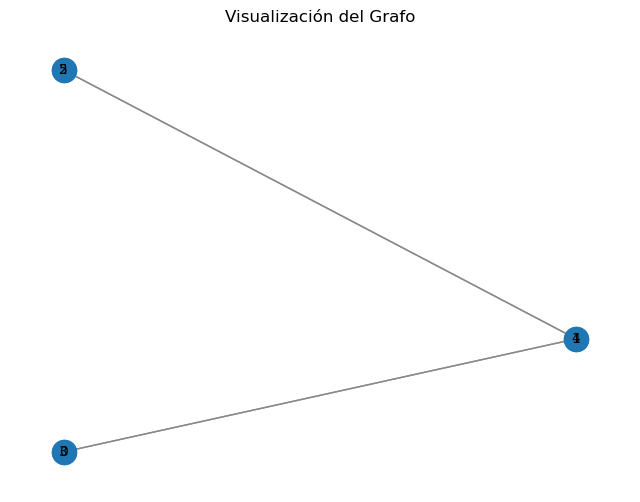

In [20]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def dibujar_grafo(data):
    # Convierte el grafo PyTorch Geometric a NetworkX
    G = to_networkx(data, edge_attrs=["edge_attr"], node_attrs=["x"], to_undirected=True)
    
    # Extrae posiciones de los nodos del atributo 'x' (coordenadas)
    pos = {i: (data.x[i, 0].item(), data.x[i, 1].item()) for i in range(data.num_nodes)}
    
    # Dibuja el grafo
    plt.figure(figsize=(8, 6))
    
    # Dibuja las aristas
    nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color="gray")
    
    # Dibuja los nodos (puedes cambiar colores según etiquetas o tiempo)
    #node_colors = ["red" if t == 0 else "blue" for t in data.x[:, 2]]  # Rojo para nodos con tiempo=0
    nx.draw_networkx_nodes(G, pos,  node_size=300)
    
    # Añade etiquetas a los nodos (índices)
    nx.draw_networkx_labels(G, pos, font_size=10, font_color="black")
    
    plt.title("Visualización del Grafo")
    plt.axis("off")
    plt.show()

# Llama a la función para dibujar el grafo
dibujar_grafo(grafo)

### Dataset

In [21]:
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data, Dataset

class GrafoDataset(Dataset):
    def __init__(self, data_rows, normalize=True):
        self.data_rows = data_rows
        self.normalize = normalize 

    def __len__(self):
        return len(self.data_rows)

    def __getitem__(self, idx):
        row = self.data_rows[idx]
        
        # Crear el grafo con posiciones
        data = crear_grafo_con_posiciones(row)
        
        # Normalizar las posiciones
        if self.normalize:
            data.x = self.normalizar_posiciones(data.x)
        
        if self.normalize and data.edge_attr is not None:
            data.edge_attr = self.normalizar_atributos(data.edge_attr)
        
        return data

    def normalizar_posiciones(self, x):
        # Usamos StandarScaler para normalizar las posiciones
        scaler = StandardScaler()
        pos = x.numpy()  # Convertir a numpy para usar el scaler
        pos_norm = scaler.fit_transform(pos)  
        return torch.tensor(pos_norm, dtype=torch.float)
    
    def normalizar_atributos(self, edge_attr):
        if edge_attr.numel() == 0:  # Si edge_attr está vacío
            #print("Warning: edge_attr vacío. No se normalizará.")
            return edge_attr  # Devuelve sin cambios
        # Usamos StandarScaler para normalizar las posiciones
        scaler = StandardScaler()
        attr = edge_attr.numpy()
        attr_norm = scaler.fit_transform(attr)
        return torch.tensor(attr_norm, dtype=torch.float)

# convertir a listas
df_segments_nodos_lista = df_segments_nodos.to_dict('records')

# dataset
dataset = GrafoDataset(df_segments_nodos_lista)

print(f"Tamaño del dataset: {len(dataset)}")
ejemplo = dataset[4]
print('Ejemplo primer grafo:', ejemplo)
print('Numero de nodos:' , ejemplo.num_nodes)
print('Nodos:', ejemplo.x)
print('Numero de aristas:', ejemplo.num_edges)
print('Aristas:', ejemplo.edge_index)
print('atributos aristas:', ejemplo.edge_attr)

Tamaño del dataset: 37077
Ejemplo primer grafo: Data(x=[4, 2], edge_index=[2, 3], edge_attr=[3, 4], y=[4])
Numero de nodos: 4
Nodos: tensor([[-1.0000, -0.6183],
        [ 1.0000,  0.9887],
        [-1.0000, -1.3192],
        [ 1.0000,  0.9488]])
Numero de aristas: 3
Aristas: tensor([[0, 1, 2],
        [1, 2, 3]])
atributos aristas: tensor([[ 0.7071, -1.4124,  0.0000,  0.7071],
        [ 0.7071,  0.7682,  0.0000,  0.7071],
        [-1.4142,  0.6441,  0.0000, -1.4142]])


### Graph Neural Network

In [22]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Dropout

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim,dropout_prob=0.5 ):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = Dropout(p=dropout_prob) # añado el dropotu para desfavorecer el sobreajuste

    def forward(self, x, edge_index):
        # convolucion + ReLU
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)  # Softmax logaritmico para clasificacion

# Usamos GPU pero si no esta disponible usamos CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')  # 'cuda' o 'cpu'

Device: cpu


### Train y tests dataset y dataloaders

In [23]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

def filtrar(dataset):
    filtered_dataset = []
    for data in dataset:
        if data.x.size(0) > 0 and (data.edge_attr is None or data.edge_attr.size(0) > 0):
            filtered_dataset.append(data)
    return filtered_dataset

# Filtrar el dataset de entrenamiento y prueba
filtred_dataset = filtrar(dataset)
print(f'Tamaño del dataset despues del filtrado: {len(filtred_dataset)}')
# Dividimos el dataset
train_dataset, test_dataset = train_test_split(filtred_dataset, test_size=0.2, random_state=42)

# Comprobamos el tamaño
print(f'Tamaño de los datasets: train = {len(train_dataset)}, test = {len(test_dataset)}' )

Tamaño del dataset despues del filtrado: 35910
Tamaño de los datasets: train = 28728, test = 7182


In [24]:
# Filtrar los grafos con NaNs
def filtrar_nans(dataset):
    filtered_dataset = []
    for data in dataset:
        if torch.isnan(data.x).sum() == 0 and torch.isnan(data.y).sum() == 0:
            filtered_dataset.append(data)
    return filtered_dataset

# Filtrar el dataset de entrenamiento y prueba
train_dataset = filtrar_nans(train_dataset)
test_dataset = filtrar_nans(test_dataset)
print(f'Tamaño de datasets despues del filtrado: train = {len(train_dataset)}, test = {len(test_dataset)}')

# Crear DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)
# 2m30s

Tamaño de datasets despues del filtrado: train = 28728, test = 7182


### Entrenamiento

Epoch 1/30, Train Loss: 0.6842, Validation Loss: 0.6817
Epoch 2/30, Train Loss: 0.6826, Validation Loss: 0.6810
Epoch 3/30, Train Loss: 0.6811, Validation Loss: 0.6766
Epoch 4/30, Train Loss: 0.6764, Validation Loss: 0.6798
Epoch 5/30, Train Loss: 0.6736, Validation Loss: 0.6740
              precision    recall  f1-score   support

     Clase 0       0.56      0.51      0.53     57821
     Clase 1       0.56      0.61      0.59     59674

    accuracy                           0.56    117495
   macro avg       0.56      0.56      0.56    117495
weighted avg       0.56      0.56      0.56    117495



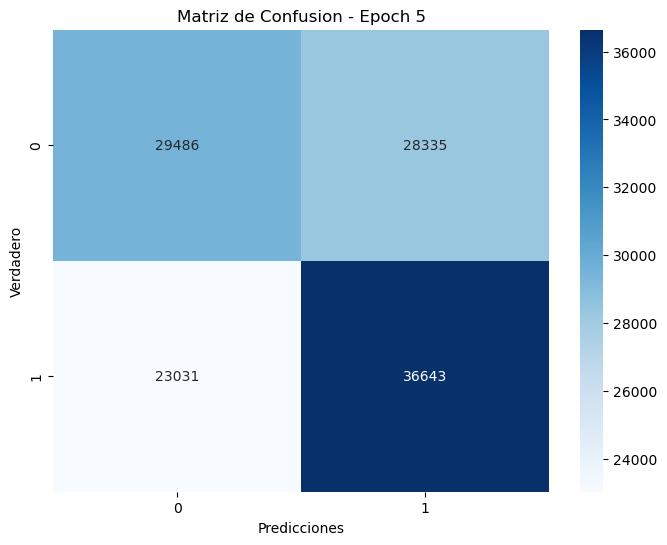

Epoch 6/30, Train Loss: 0.6716, Validation Loss: 0.6730
Epoch 7/30, Train Loss: 0.6700, Validation Loss: 0.6684
Epoch 8/30, Train Loss: 0.6684, Validation Loss: 0.6664
Epoch 9/30, Train Loss: 0.6680, Validation Loss: 0.6743
Epoch 10/30, Train Loss: 0.6677, Validation Loss: 0.6658
              precision    recall  f1-score   support

     Clase 0       0.58      0.55      0.57     57821
     Clase 1       0.59      0.61      0.60     59674

    accuracy                           0.58    117495
   macro avg       0.58      0.58      0.58    117495
weighted avg       0.58      0.58      0.58    117495



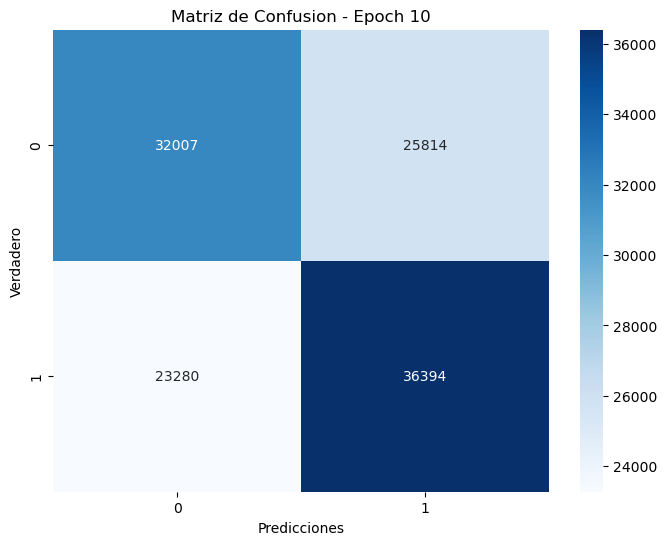

Epoch 11/30, Train Loss: 0.6676, Validation Loss: 0.6727
Epoch 12/30, Train Loss: 0.6676, Validation Loss: 0.6721
Epoch 13/30, Train Loss: 0.6675, Validation Loss: 0.6665
Epoch 14/30, Train Loss: 0.6677, Validation Loss: 0.6655
Epoch 15/30, Train Loss: 0.6677, Validation Loss: 0.6653
              precision    recall  f1-score   support

     Clase 0       0.57      0.56      0.57     57821
     Clase 1       0.58      0.60      0.59     59674

    accuracy                           0.58    117495
   macro avg       0.58      0.58      0.58    117495
weighted avg       0.58      0.58      0.58    117495



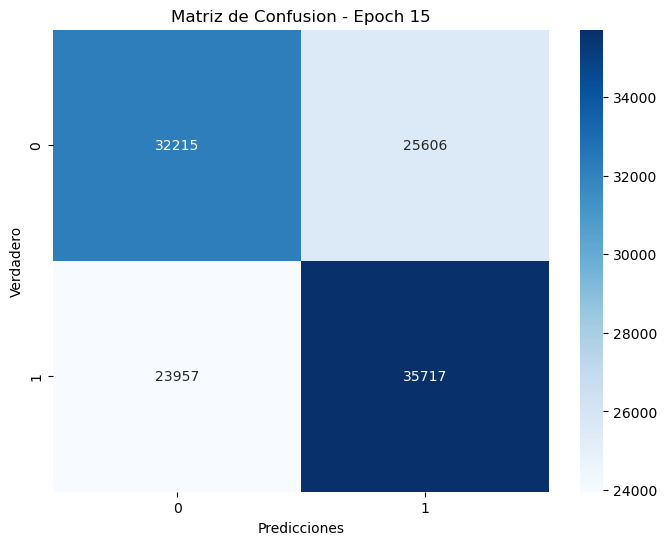

Epoch 16/30, Train Loss: 0.6675, Validation Loss: 0.6673
Epoch 17/30, Train Loss: 0.6675, Validation Loss: 0.6646
Epoch 18/30, Train Loss: 0.6676, Validation Loss: 0.6655
Epoch 19/30, Train Loss: 0.6676, Validation Loss: 0.6681
Epoch 20/30, Train Loss: 0.6678, Validation Loss: 0.6715
              precision    recall  f1-score   support

     Clase 0       0.57      0.56      0.56     57821
     Clase 1       0.58      0.60      0.59     59674

    accuracy                           0.58    117495
   macro avg       0.58      0.58      0.58    117495
weighted avg       0.58      0.58      0.58    117495



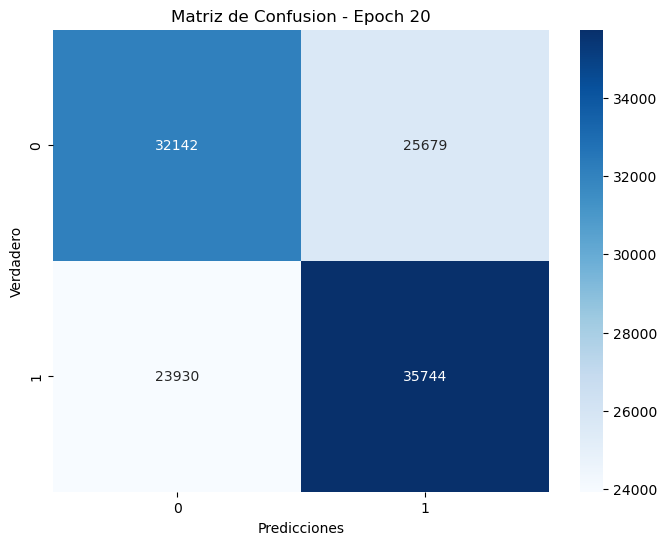

Epoch 21/30, Train Loss: 0.6676, Validation Loss: 0.6656
Epoch 22/30, Train Loss: 0.6677, Validation Loss: 0.6653
Epoch 23/30, Train Loss: 0.6677, Validation Loss: 0.6684
Epoch 24/30, Train Loss: 0.6674, Validation Loss: 0.6672
Epoch 25/30, Train Loss: 0.6676, Validation Loss: 0.6683
              precision    recall  f1-score   support

     Clase 0       0.58      0.55      0.56     57821
     Clase 1       0.58      0.61      0.59     59674

    accuracy                           0.58    117495
   macro avg       0.58      0.58      0.58    117495
weighted avg       0.58      0.58      0.58    117495



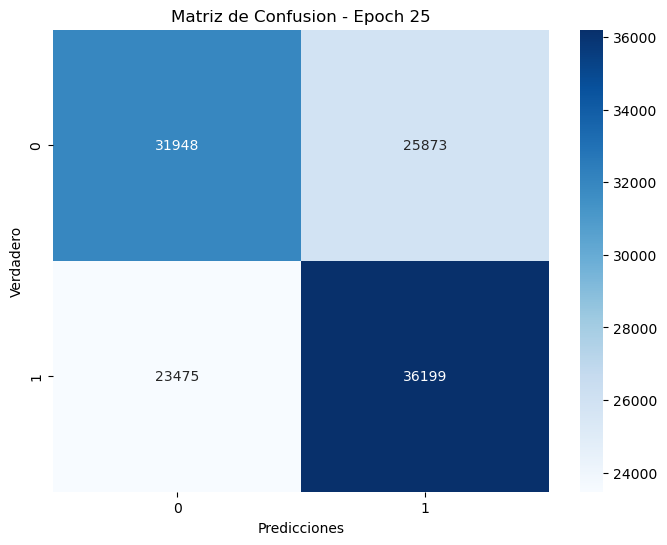

Epoch 26/30, Train Loss: 0.6673, Validation Loss: 0.6668
Epoch 27/30, Train Loss: 0.6674, Validation Loss: 0.6701
Epoch 28/30, Train Loss: 0.6679, Validation Loss: 0.6647
Epoch 29/30, Train Loss: 0.6674, Validation Loss: 0.6660
Epoch 30/30, Train Loss: 0.6678, Validation Loss: 0.6656
              precision    recall  f1-score   support

     Clase 0       0.58      0.56      0.57     57821
     Clase 1       0.58      0.60      0.59     59674

    accuracy                           0.58    117495
   macro avg       0.58      0.58      0.58    117495
weighted avg       0.58      0.58      0.58    117495



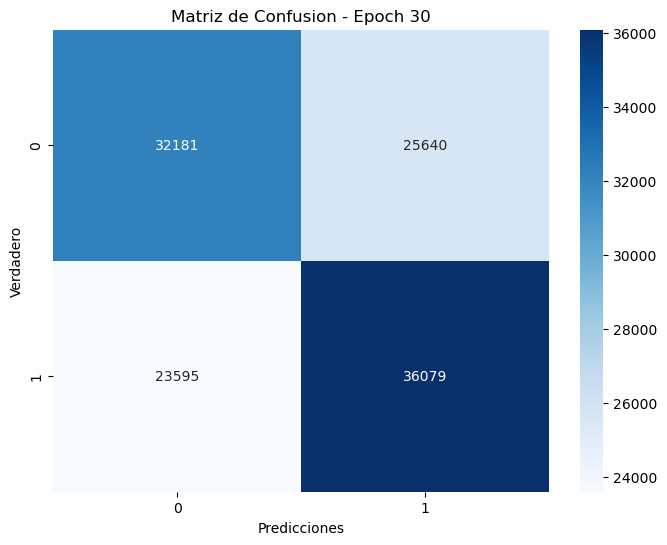

In [25]:
from torch.nn import CrossEntropyLoss
import torch
from sklearn.metrics import confusion_matrix, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

#para plotear la matriz de confusion
def plot_confusion(all_preds,all_labels,epoch):
    # matriz de confusion y el F1-score
    cm = confusion_matrix(all_labels, all_preds)
    print(classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"]))

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.title(f'Matriz de Confusion - Epoch {epoch + 1}')
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.show()

# Parametros
input_dim = 2   # x, y positions
hidden_dim = 25
output_dim = 2  # Numero de clases (nodo verdad 1 o no 0)

# modelo, optimizador y perdida
model = GCN(input_dim, hidden_dim, output_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
loss_fn = CrossEntropyLoss()

# epocas
epochs = 30

# para hacer las curvas de aprendizaje necesito almacenar las perdidas y precision
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# entrenamiento
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    all_preds = []  # almacenar las predicciones
    all_labels = []  # almacenar las etiquetas verdaderas

    for data in train_loader:
        # Verificar si el grafo tiene aristas
        if data.edge_index.numel() == 0:  
            continue 

        optimizer.zero_grad()
        
        # Forward pass
        out = model(data.x, data.edge_index)
        
        # Calcular perdida
        loss = loss_fn(out, data.y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Obtener predicciones y etiquetas verdaderas
        preds = out.argmax(dim=1).cpu().numpy()  # Predicciones
        labels = data.y.cpu().numpy()  # Etiquetas verdaderas

        all_preds.extend(preds)
        all_labels.extend(labels)

    train_losses.append(epoch_loss/len(train_loader))
    train_accuracies.append(f1_score(all_labels, all_preds))

    #evaluar modelo
    model.eval()
    val_loss = 0
    all_preds_val = []
    all_labels_val = []
    with torch.no_grad():
        for data in test_loader:
            if data.edge_index.numel() == 0:  
                continue 
            
            data = data.to(device)
            logits = model(data.x, data.edge_index)
            loss = loss_fn(logits, data.y)
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds_val.append(preds.cpu())
            all_labels_val.append(data.y.cpu())  
    val_losses.append(val_loss/len(test_loader))
    all_preds_val = torch.cat(all_preds_val).numpy()
    all_labels_val = torch.cat(all_labels_val).numpy()
    val_accuracies.append(f1_score(all_labels_val, all_preds_val))
    
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(test_loader):.4f}")
    if (epoch+1)%5 == 0:
        plot_confusion(all_preds, all_labels, epoch)


### Curvas aprendizaje

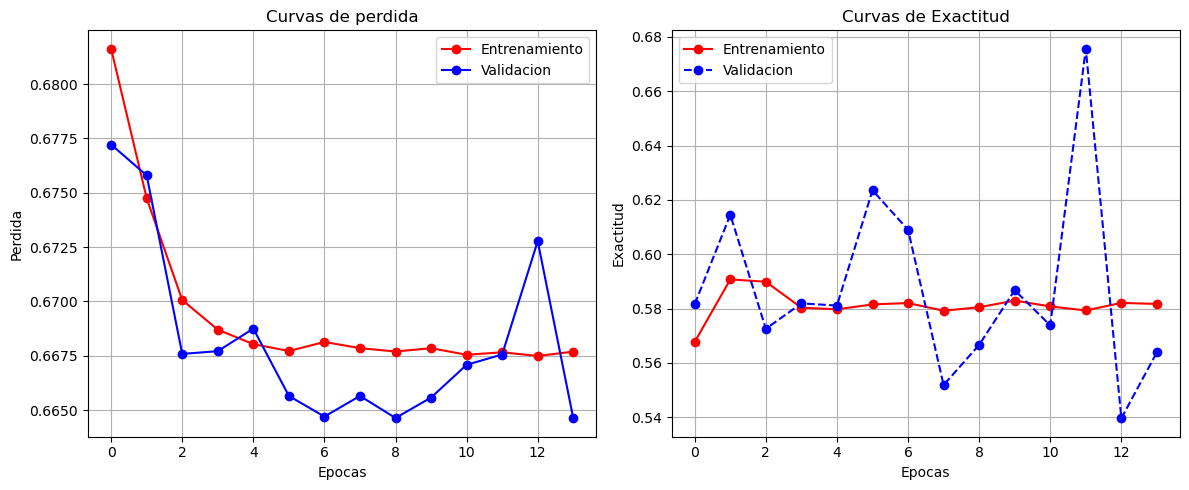

In [79]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].plot(train_losses, 'o-', color='red',label='Entrenamiento')
ax[0].plot(val_losses, 'o-', color='blue',label='Validacion')
ax[0].set_xlabel('Epocas')
ax[0].set_ylabel('Perdida')
ax[0].set_title('Curvas de perdida')
ax[0].grid()
ax[0].legend()

ax[1].plot(train_accuracies, 'o-', color='red', label = 'Entrenamiento')
ax[1].plot(val_accuracies, 'o--', color='blue',label = 'Validacion')
ax[1].set_xlabel('Epocas')
ax[1].set_ylabel('Exactitud')
ax[1].set_title('Curvas de Exactitud')
ax[1].grid()
ax[1].legend()
plt.tight_layout()
plt.show()

(array([19893.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 21466.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

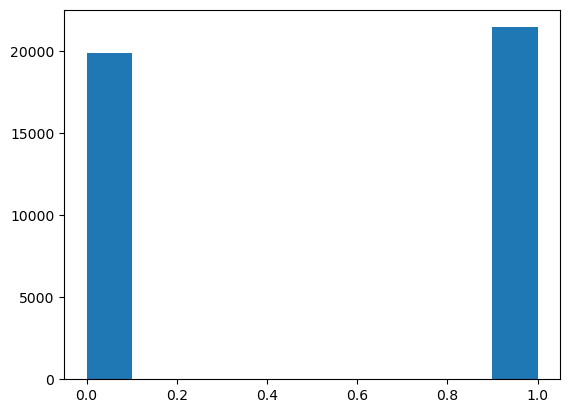

In [80]:
plt.hist(all_preds)

### Ver datos 

In [81]:
# Visualizar un lote de datos para ver que esta pasando
def ver_datos(dataloader, n=1):
    #n es el numero de grafos que quieres ver
    for i, data in enumerate(dataloader):
        print(f"Batch {i + 1}:")
        print(f"x (nodos): {data.x.shape}")
        print(f"edge_index (aristas): {data.edge_index.shape}")
        print(f"data.y.shape: {data.y.shape}")
        print(f"data.y.numpy: {data.y.numpy()}")
        print(f"data.edge_attr.shape: {data.edge_attr.shape}")
        print(f"data.edge_attr.numpy: {data.edge_attr.numpy()}")
        
        # Imprimir nodos, aristas y atributos
        print(f"Nodos: {data.x[:]}")
        print(f"aristas: {data.edge_index[:, :]}")
        print(f" etiquetas de aristas: {data.y[:]}")
        print('\n')
        
        if i == n:
            break
# recuerda q aparecen 20 nodos porque el batchsize es 2, entonces ha concatenado 2 grafos
ver_datos(train_loader)

Batch 1:
x (nodos): torch.Size([7, 2])
edge_index (aristas): torch.Size([2, 5])
data.y.shape: torch.Size([7])
data.y.numpy: [1 1 0 1 1 0 0]
data.edge_attr.shape: torch.Size([5, 2])
data.edge_attr.numpy: [[ 0.          1.        ]
 [ 0.         -1.        ]
 [-0.7071051   0.59176445]
 [-0.7071085  -1.4082495 ]
 [ 1.4142135   0.8164851 ]]
Nodos: tensor([[ 7.0711e-01,  1.3893e+00],
        [-1.4142e+00, -4.6593e-01],
        [ 7.0711e-01, -9.2340e-01],
        [-8.1650e-01, -1.1751e+00],
        [-1.4832e-06,  6.9039e-01],
        [-8.1649e-01,  1.2486e+00],
        [ 1.6330e+00, -7.6384e-01]])
aristas: tensor([[0, 1, 3, 4, 5],
        [1, 2, 4, 5, 6]])
 etiquetas de aristas: tensor([1, 1, 0, 1, 1, 0, 0])


Batch 2:
x (nodos): torch.Size([5, 2])
edge_index (aristas): torch.Size([2, 3])
data.y.shape: torch.Size([5])
data.y.numpy: [1 0 1 0 0]
data.edge_attr.shape: torch.Size([3, 2])
data.edge_attr.numpy: [[-1.  1.]
 [ 1. -1.]
 [ 0.  0.]]
Nodos: tensor([[-2.2248e-06,  1.4138e+00],
        [-

### Validacion

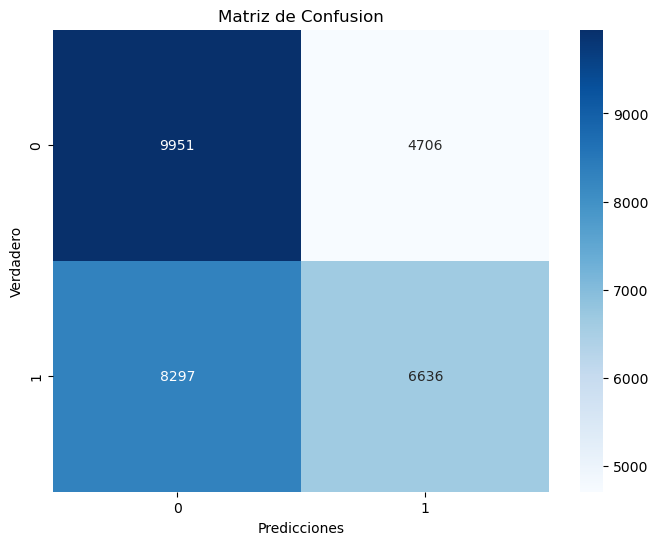

{'0': {'precision': 0.5453200350723367, 'recall': 0.6789247458552228, 'f1-score': 0.6048320923871752, 'support': 14657.0}, '1': {'precision': 0.5850819961206136, 'recall': 0.4443849193062345, 'f1-score': 0.5051189343482397, 'support': 14933.0}, 'accuracy': 0.560561000337952, 'macro avg': {'precision': 0.5652010155964752, 'recall': 0.5616548325807287, 'f1-score': 0.5549755133677075, 'support': 29590.0}, 'weighted avg': {'precision': 0.5653864549551998, 'recall': 0.560561000337952, 'f1-score': 0.5545104773484654, 'support': 29590.0}}


In [82]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar_modelo(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Desactivar gradientes
    with torch.no_grad():
        for data in dataloader:
            if data.edge_index.numel() == 0:
                print(data)  
                continue 
            data = data.to(device)
            logits = model(data.x, data.edge_index)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(data.y.cpu())
    
    # Concatenar predicciones y etiquetas reales
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    # Calcular metricas
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, output_dict=True)
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.title(f'Matriz de Confusion')
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.show()
    
    return report, all_preds, all_labels

report, all_preds, all_labels = evaluar_modelo(model, test_loader, device)
print(report)


### ROC y AUC

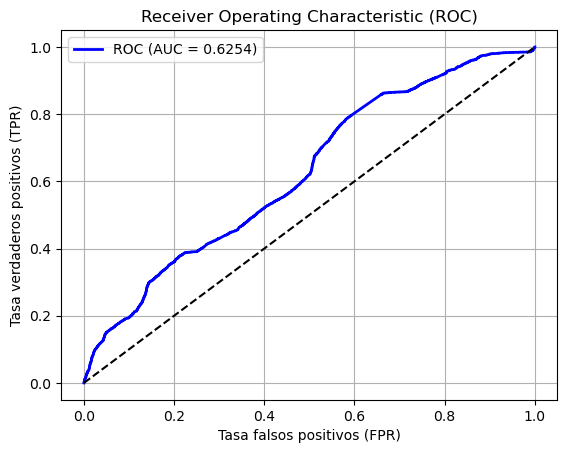

In [83]:
from sklearn.metrics import roc_curve, auc
def probs_labels(model, dataloader, device):
    all_probs = []  # Probabilidades para la clase positiva
    all_labels = []  # Etiquetas verdaderas

    model.eval()
    with torch.no_grad():
        for data in dataloader:
            if data.edge_index.numel() == 0:  
                continue 
            out = model(data.x, data.edge_index)
            probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()  # Probabilidades de la clase 1
            labels = data.y.cpu().numpy()

            all_probs.extend(probs.tolist()) 
            all_labels.extend(labels.tolist()) 
    return all_probs, all_labels

def roc_y_auc(all_probs, all_labels):
    FPR, TPR, _ = roc_curve(all_labels, all_probs) #tasa falsos positivos y tasa verdaderos positivos
    roc_auc = auc(FPR, TPR) #area bajo la ROC

    plt.figure()
    plt.plot(FPR, TPR, color ='b', lw=2, label = f'ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Línea diagonal
    plt.xlabel('Tasa falsos positivos (FPR)')
    plt.ylabel('Tasa verdaderos positivos (TPR)')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.grid()
    plt.legend()
    plt.show()

all_probs, all_labels = probs_labels(model, test_loader, device)
roc_y_auc(all_probs, all_labels)


### Curva precision recall

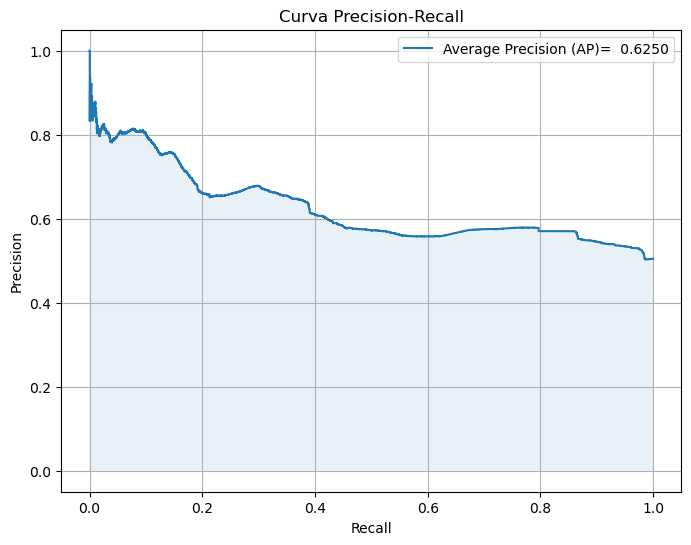

In [84]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def precision_recall(all_labels, all_probs):
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    average_precision = average_precision_score(all_labels, all_probs)

    plt.figure(figsize = (8,6))
    plt.step(recall, precision, where = 'post', label = f'Average Precision (AP)= {average_precision: .4f}')
    plt.fill_between(recall, precision, step='post', alpha = 0.1)
    plt.title('Curva Precision-Recall')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

precision_recall(all_labels,all_probs)
